In [6]:
# =============================================================================
#  MAIN VISUALIZATION PLOTS — 8 KEY PLOTS
#  Project : Crop Yield Prediction Using Environmental and Nutrient Factors
#  Course  : Data Warehousing and Data Mining (DWDM)
#  Library : seaborn + matplotlib
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
%matplotlib inline

# GLOBAL STYLE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"       : 130,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F9FAFB",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

MAIN_GREEN      = "#1B5E20"
CATEGORY_COLORS = {"Low": "#E53935", "Medium": "#FB8C00", "High": "#43A047"}
SEASON_COLORS   = {"Kharif": "#1565C0", "Rabi": "#6A1B9A", "Annual": "#2E7D32"}

In [7]:
# LOAD DATA

print("Loading dataset...")
df = pd.read_csv("crop_yield_cleaned_dataset.csv")
df["Pest_Incidence"]    = df["Pest_Incidence"].fillna("None")
df["Disease_Incidence"] = df["Disease_Incidence"].fillna("None")

df_sample = df.sample(n=30000, random_state=42)

print(f"Dataset loaded : {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Generating 8 main plots...\n")

# HELPER — save figure

# def save(fig, filename):
#     fig.tight_layout()
#     fig.savefig(filename, bbox_inches="tight")
#     plt.close(fig)
#     print(f"  Saved → {filename}")

Loading dataset...
Dataset loaded : 220,000 rows x 36 columns
Generating 8 main plots...



Plot 1 : Yield Distribution by Crop Type (Box Plot)


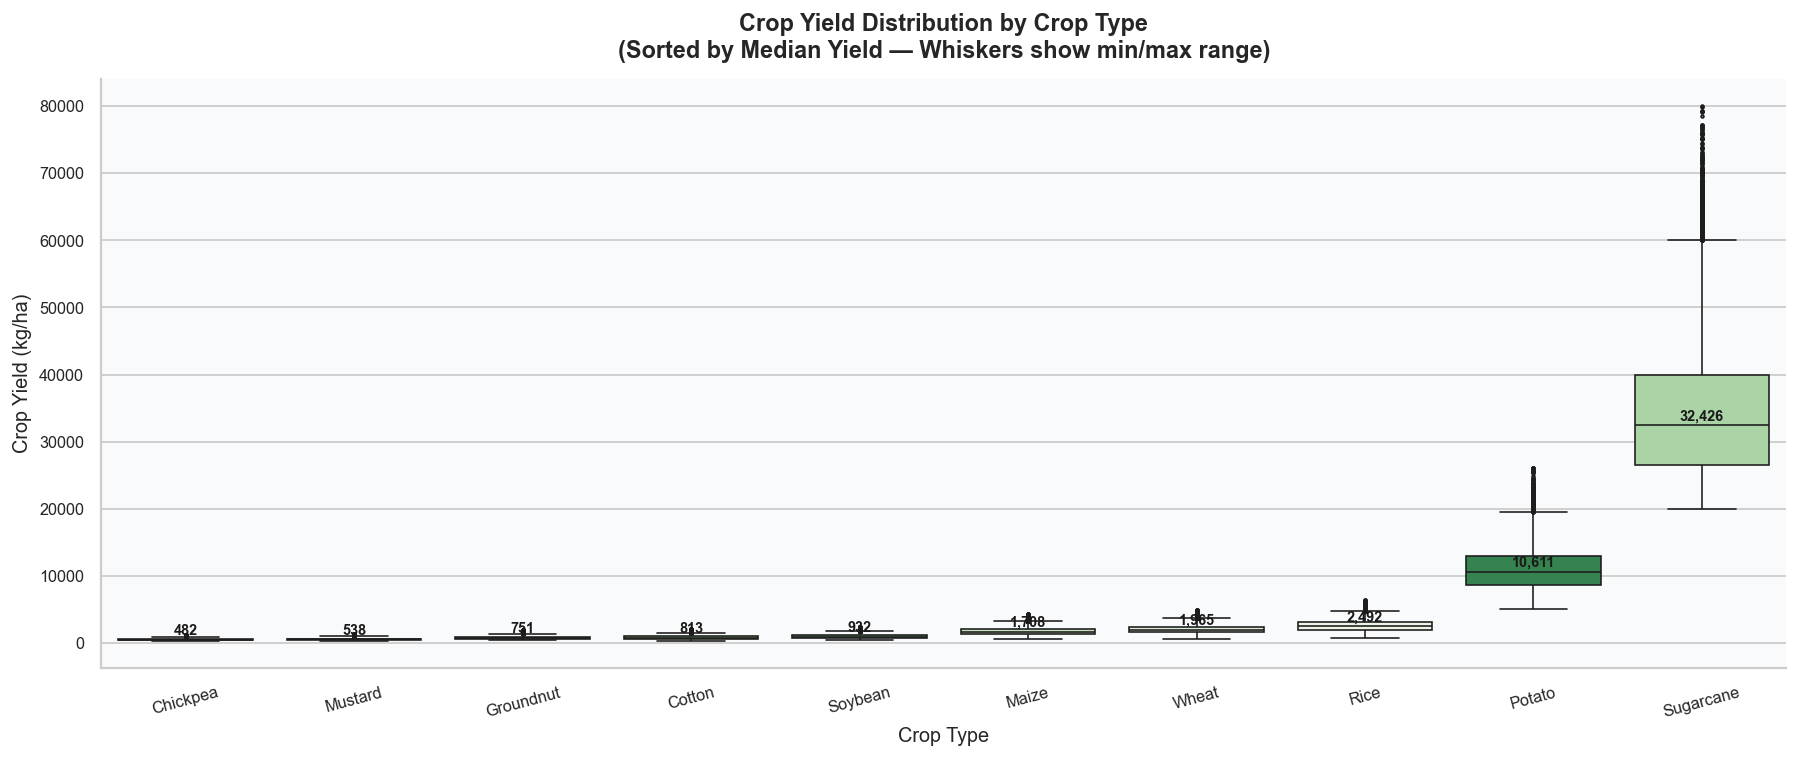

In [9]:
# PLOT 1 — YIELD DISTRIBUTION BY CROP TYPE  (Box Plot)

print("Plot 1 : Yield Distribution by Crop Type (Box Plot)")
fig, ax = plt.subplots(figsize=(14, 6))

crop_order = (
    df.groupby("Crop_Type")["Crop_Yield_kg_ha"]
    .median()
    .sort_values()
    .index
    .tolist()
)

sns.boxplot(
    data=df,
    x="Crop_Type",
    y="Crop_Yield_kg_ha",
    order=crop_order,
    hue="Crop_Type",        
    palette="Greens",
    legend=False,            
    fliersize=1.5,
    linewidth=0.9,
    ax=ax
)

# Annotate median value on each box
for i, crop in enumerate(crop_order):
    median = df[df["Crop_Type"] == crop]["Crop_Yield_kg_ha"].median()
    ax.text(
        i, median + 300,
        f"{median:,.0f}",
        ha="center", va="bottom",
        fontsize=8, fontweight="bold", color="#1A1A1A"
    )

ax.set_title(
    "Crop Yield Distribution by Crop Type\n"
    "(Sorted by Median Yield — Whiskers show min/max range)",
    pad=12
)
ax.set_xlabel("Crop Type")
ax.set_ylabel("Crop Yield (kg/ha)")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()          

# save(fig, "main_plot1_yield_by_crop_boxplot.png")

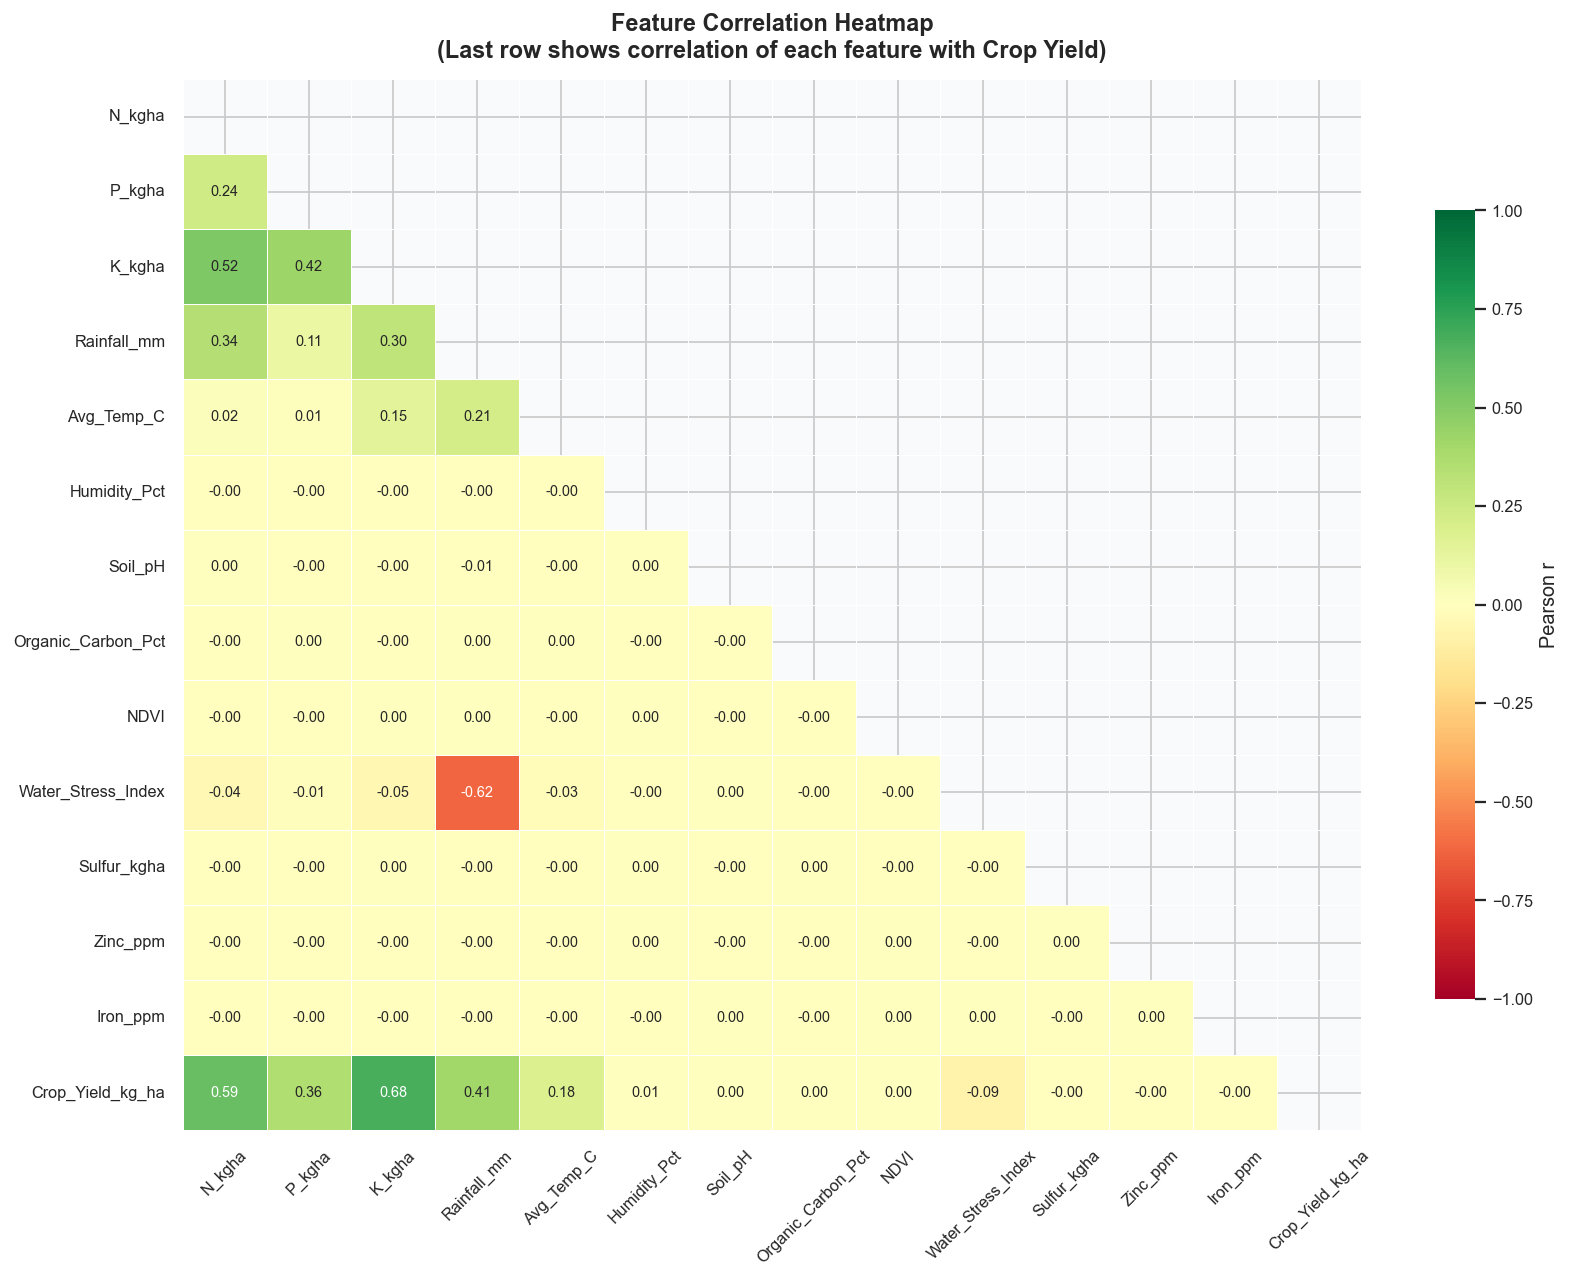

In [10]:
# PLOT 2 — CORRELATION HEATMAP

num_cols = [
    "N_kgha", "P_kgha", "K_kgha",
    "Rainfall_mm", "Avg_Temp_C", "Humidity_Pct",
    "Soil_pH", "Organic_Carbon_Pct",
    "NDVI", "Water_Stress_Index",
    "Sulfur_kgha", "Zinc_ppm", "Iron_ppm",
    "Crop_Yield_kg_ha"
]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))

# Mask the upper triangle to show only lower triangle (cleaner look)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
    ax=ax,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"}
)

ax.set_title(
    "Feature Correlation Heatmap\n"
    "(Last row shows correlation of each feature with Crop Yield)",
    pad=12
)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# save(fig, "main_plot2_correlation_heatmap.png")

Plot 3 : NPK vs Yield (3-panel Scatter)


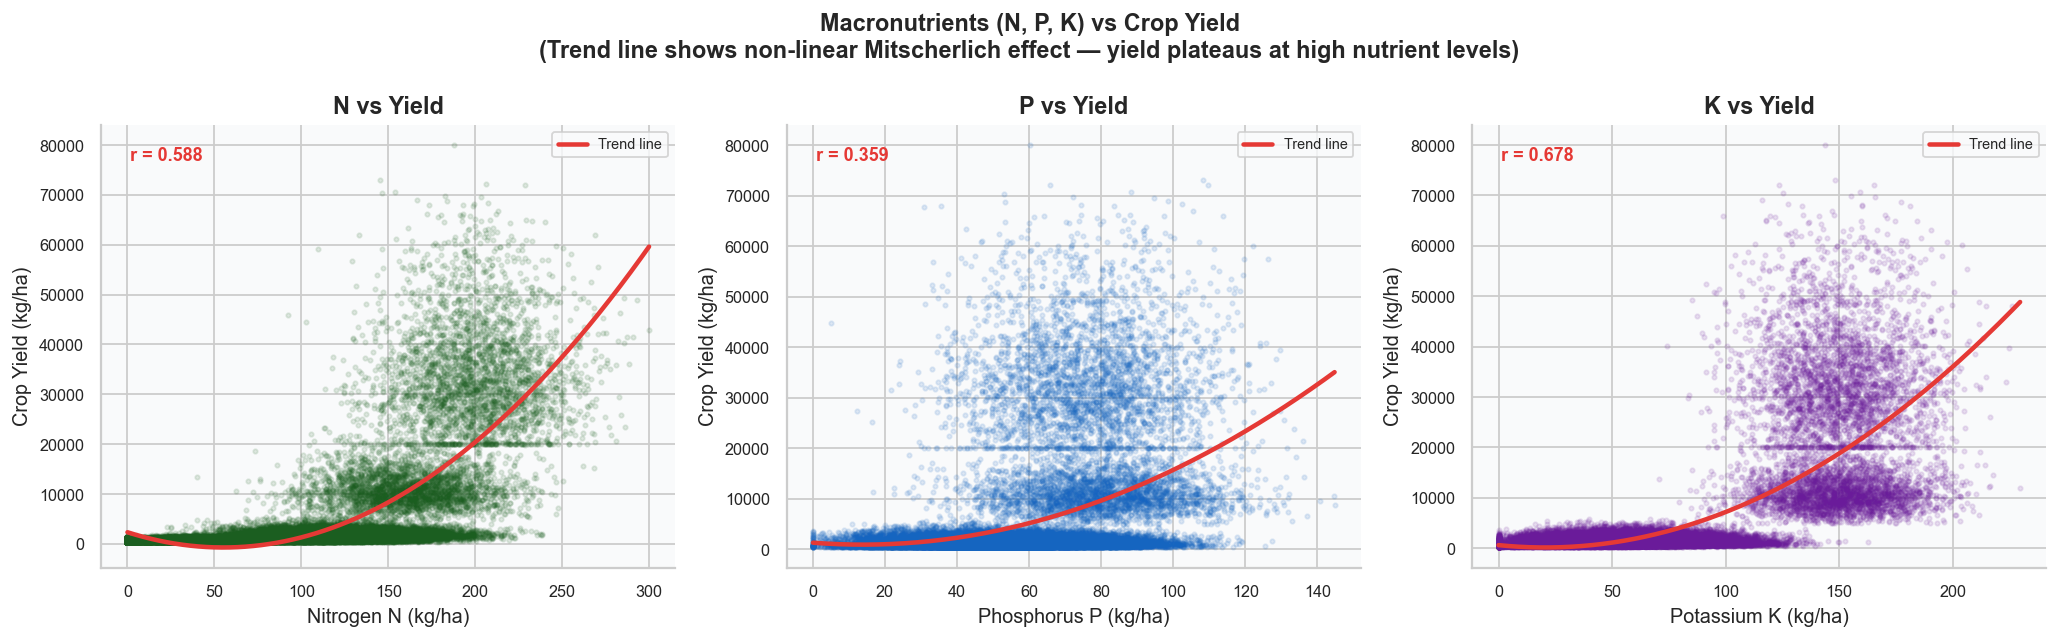

In [11]:
# PLOT 3 — NPK vs YIELD  (3-panel Scatter with Trend Line)

print("Plot 3 : NPK vs Yield (3-panel Scatter)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Macronutrients (N, P, K) vs Crop Yield\n"
    "(Trend line shows non-linear Mitscherlich effect — yield plateaus at high nutrient levels)",
    fontsize=13, fontweight="bold"
)

nutrients = [
    ("N_kgha",  "Nitrogen N (kg/ha)",     "#1B5E20"),
    ("P_kgha",  "Phosphorus P (kg/ha)",   "#1565C0"),
    ("K_kgha",  "Potassium K (kg/ha)",    "#6A1B9A"),
]

for ax, (col, label, color) in zip(axes, nutrients):

    # Scatter plot (30k sample — representative)
    ax.scatter(
        df_sample[col],
        df_sample["Crop_Yield_kg_ha"],
        c=color, alpha=0.12, s=6
    )

    # Polynomial trend line (degree 2 — captures the curve)
    x_vals = df_sample[col].values
    y_vals = df_sample["Crop_Yield_kg_ha"].values
    z      = np.polyfit(x_vals, y_vals, 2)
    p      = np.poly1d(z)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
    ax.plot(
        x_line, p(x_line),
        color="#E53935", linewidth=2.5,
        label="Trend line"
    )

    # Correlation annotation
    corr_val = df_sample[[col, "Crop_Yield_kg_ha"]].corr().iloc[0, 1]
    ax.text(
        0.05, 0.92,
        f"r = {corr_val:.3f}",
        transform=ax.transAxes,
        fontsize=10, fontweight="bold",
        color="#E53935"
    )

    ax.set_xlabel(label)
    ax.set_ylabel("Crop Yield (kg/ha)")
    ax.set_title(f"{col.split('_')[0]} vs Yield")
    ax.legend(fontsize=8)
    
plt.tight_layout()
plt.show()
# save(fig, "main_plot3_npk_vs_yield.png")

Plot 4 : Yield Trend Over Years (2000-2023)


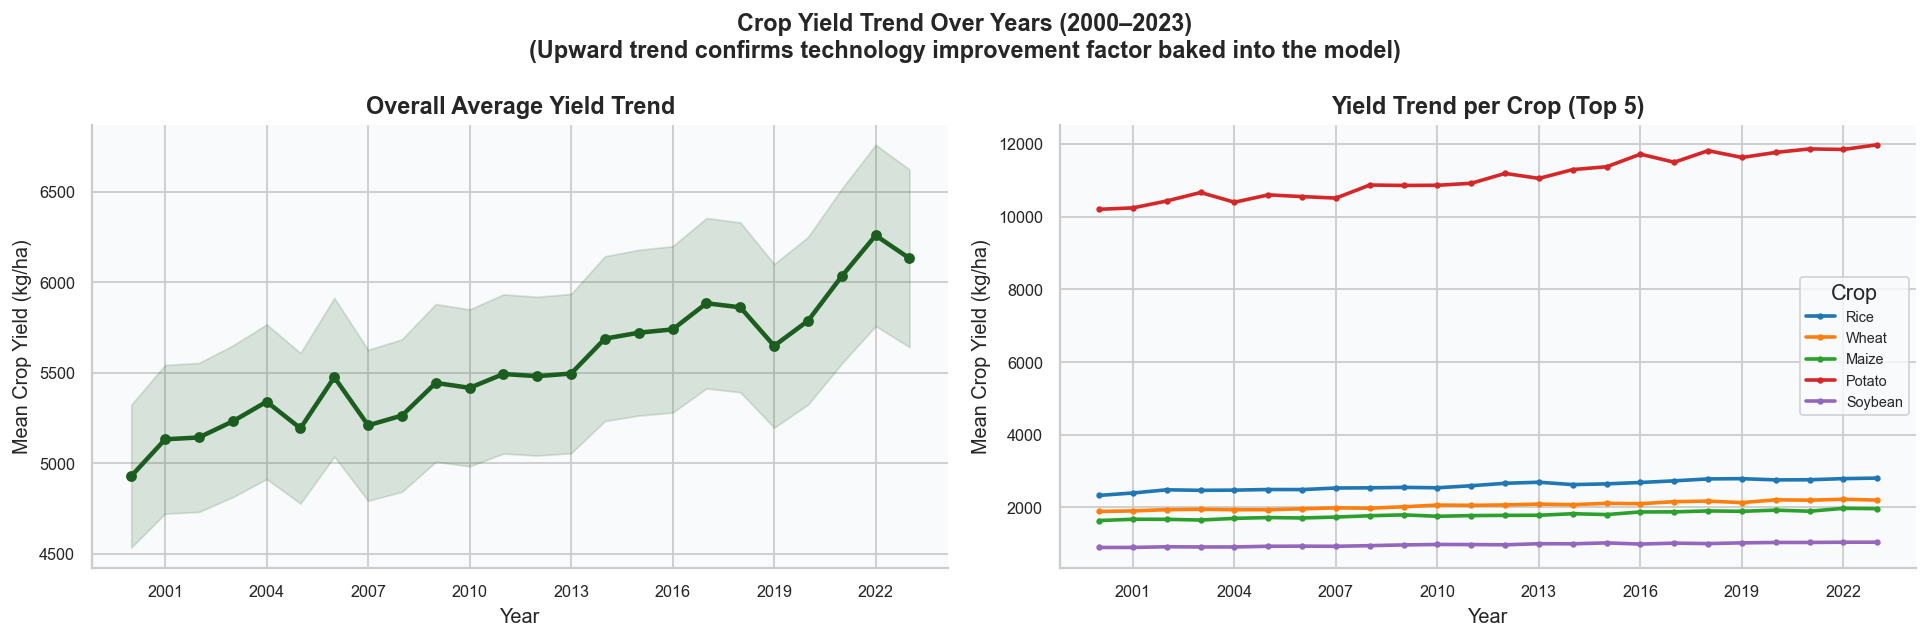

In [12]:
# PLOT 4 — YIELD TREND OVER YEARS  (Line Chart)

print("Plot 4 : Yield Trend Over Years (2000-2023)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Crop Yield Trend Over Years (2000–2023)\n"
    "(Upward trend confirms technology improvement factor baked into the model)",
    fontsize=13, fontweight="bold"
)

# Left — overall trend
yearly = (
    df.groupby("Year")["Crop_Yield_kg_ha"]
    .mean()
    .reset_index()
)

axes[0].plot(
    yearly["Year"], yearly["Crop_Yield_kg_ha"],
    marker="o", color=MAIN_GREEN,
    linewidth=2.5, markersize=5,
    label="Mean yield"
)
# Shaded confidence band
axes[0].fill_between(
    yearly["Year"],
    yearly["Crop_Yield_kg_ha"] * 0.92,
    yearly["Crop_Yield_kg_ha"] * 1.08,
    alpha=0.15, color=MAIN_GREEN
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean Crop Yield (kg/ha)")
axes[0].set_title("Overall Average Yield Trend")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(3))

# Right — per crop trend (top 5 for clarity)
top5    = ["Rice", "Wheat", "Maize", "Potato", "Soybean"]
palette = sns.color_palette("tab10", 5)

for i, crop in enumerate(top5):
    yc = (
        df[df["Crop_Type"] == crop]
        .groupby("Year")["Crop_Yield_kg_ha"]
        .mean()
        .reset_index()
    )
    axes[1].plot(
        yc["Year"], yc["Crop_Yield_kg_ha"],
        marker=".", color=palette[i],
        linewidth=2, markersize=5, label=crop
    )

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean Crop Yield (kg/ha)")
axes[1].set_title("Yield Trend per Crop (Top 5)")
axes[1].legend(title="Crop", fontsize=8)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(3))

plt.tight_layout()
plt.show()

# save(fig, "main_plot4_yield_trend_years.png")

Plot 5 : Yield by Season (Violin Plot)


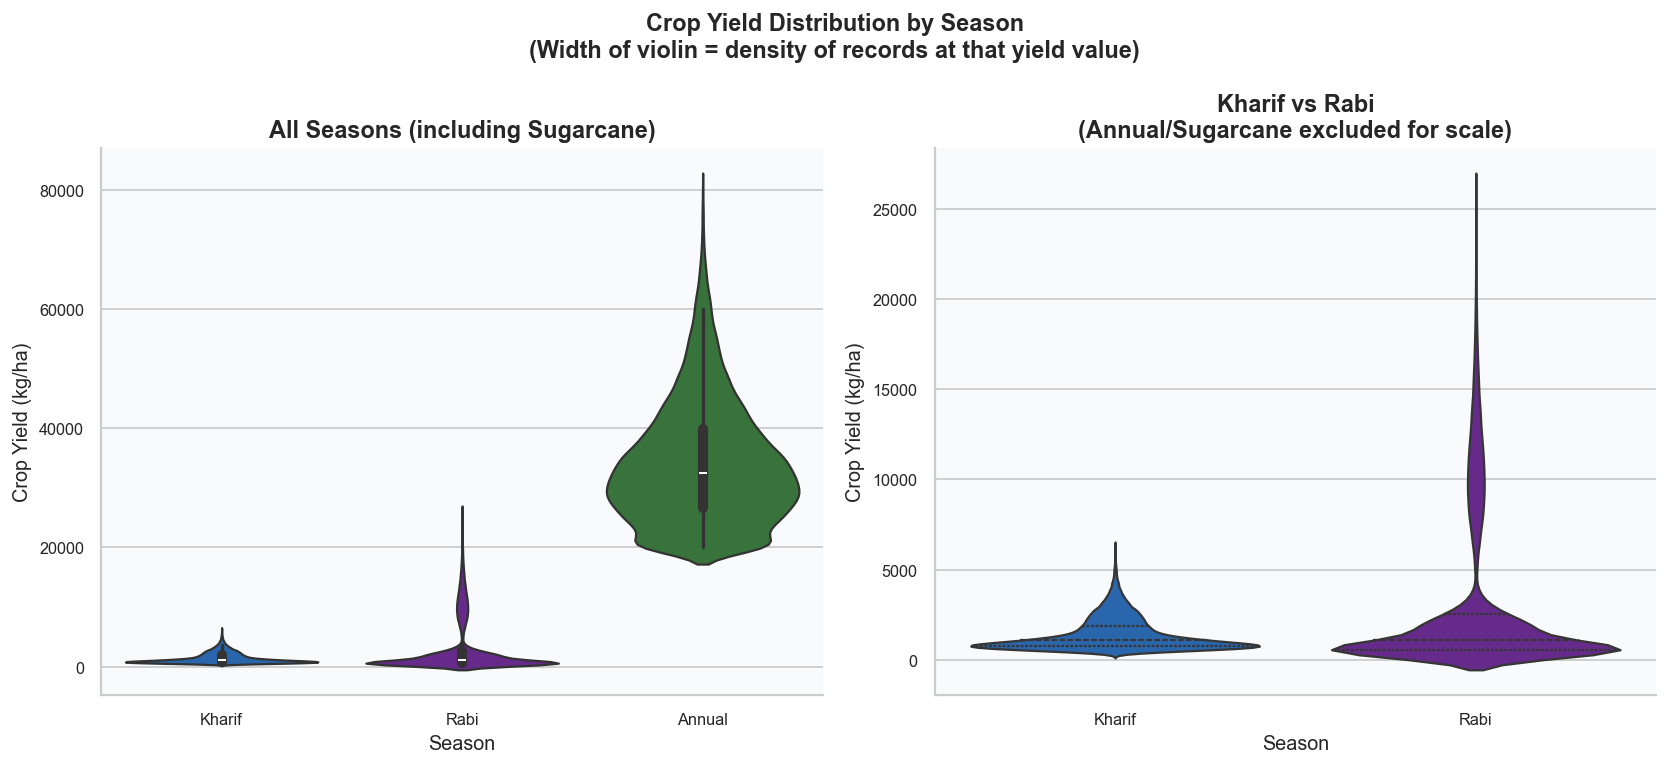

In [15]:
# PLOT 5 — YIELD BY SEASON  (Violin Plot)

print("Plot 5 : Yield by Season (Violin Plot)")
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(
    "Crop Yield Distribution by Season\n"
    "(Width of violin = density of records at that yield value)",
    fontsize=13, fontweight="bold"
)

# Left — all seasons including Annual (Sugarcane)
sns.violinplot(
    data=df,
    x="Season",
    y="Crop_Yield_kg_ha",
    order=["Kharif", "Rabi", "Annual"],
    hue="Season",                         
    palette=SEASON_COLORS,
    legend=False,                         
    inner="box",
    ax=axes[0]
)
axes[0].set_title("All Seasons (including Sugarcane)")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Crop Yield (kg/ha)")

# Right — Kharif vs Rabi only (Annual/Sugarcane removed to see detail)
df_no_annual = df[df["Season"] != "Annual"]
sns.violinplot(
    data=df_no_annual,
    x="Season",
    y="Crop_Yield_kg_ha",
    order=["Kharif", "Rabi"],
    hue="Season",                         
    palette={"Kharif": "#1565C0", "Rabi": "#6A1B9A"},
    legend=False,                          
    inner="quartile",
    ax=axes[1]
)
axes[1].set_title("Kharif vs Rabi\n(Annual/Sugarcane excluded for scale)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Crop Yield (kg/ha)")

plt.tight_layout()
plt.show()

# save(fig, "main_plot5_yield_by_season_violin.png")

Plot 6 : Yield by State (Horizontal Bar)


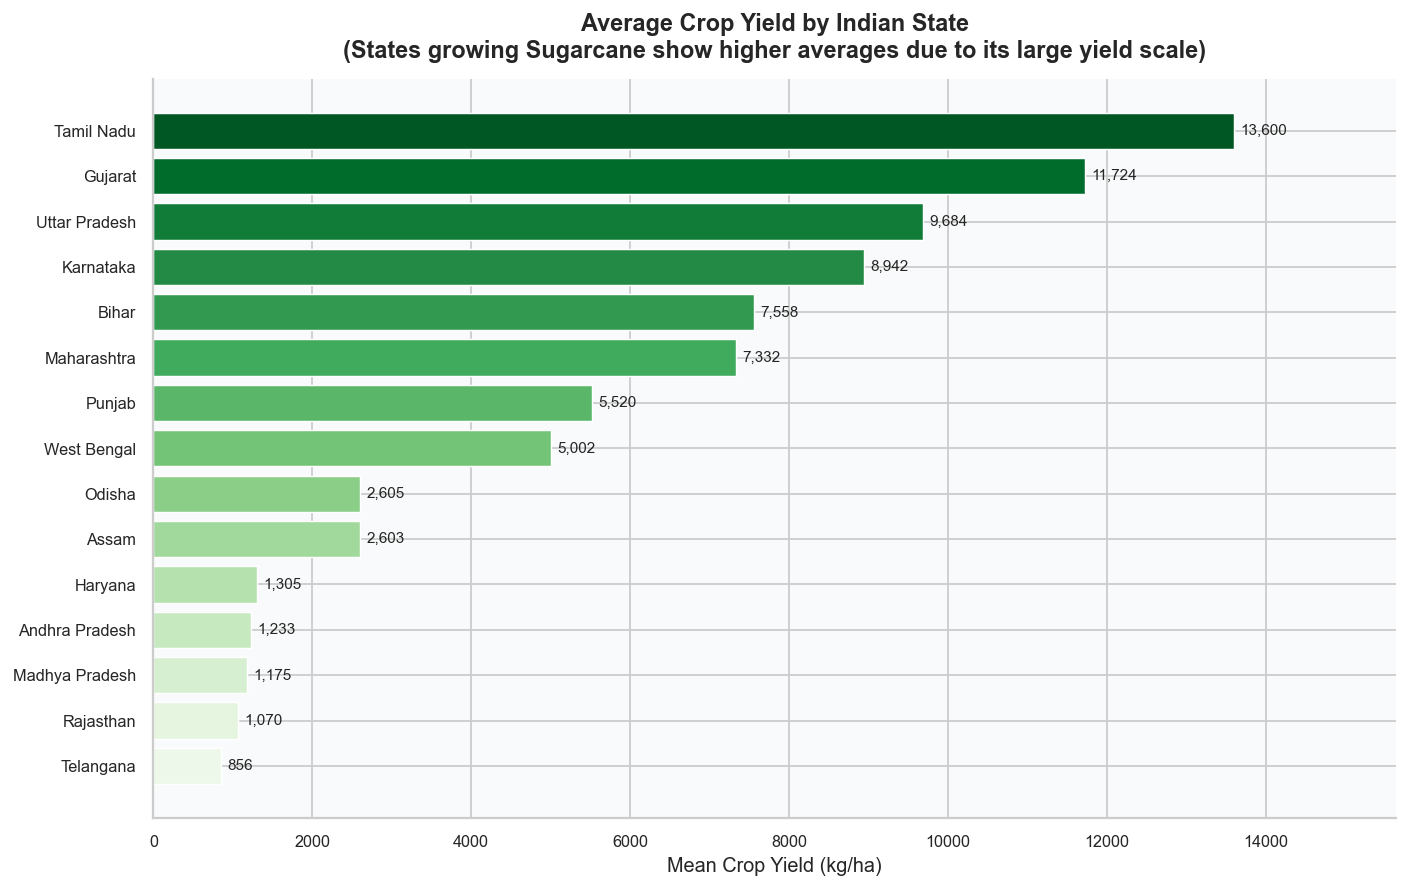

In [16]:
# PLOT 6 — YIELD BY STATE  (Horizontal Bar Chart)

print("Plot 6 : Yield by State (Horizontal Bar)")

fig, ax = plt.subplots(figsize=(11, 7))

state_stats = (
    df.groupby("State")["Crop_Yield_kg_ha"]
    .mean()
    .reset_index()
    .sort_values("Crop_Yield_kg_ha", ascending=True)
)

colors = sns.color_palette("Greens", n_colors=len(state_stats))

bars = ax.barh(
    state_stats["State"],
    state_stats["Crop_Yield_kg_ha"],
    color=colors,
    edgecolor="white",
    linewidth=0.8
)

# Annotate bar values
for bar, val in zip(bars, state_stats["Crop_Yield_kg_ha"]):
    ax.text(
        bar.get_width() + 80,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}",
        va="center", fontsize=8.5
    )

ax.set_xlabel("Mean Crop Yield (kg/ha)")
ax.set_title(
    "Average Crop Yield by Indian State\n"
    "(States growing Sugarcane show higher averages due to its large yield scale)",
    pad=12
)
ax.set_xlim(0, state_stats["Crop_Yield_kg_ha"].max() * 1.15)

plt.tight_layout()
plt.show()

# save(fig, "main_plot6_yield_by_state.png")

Plot 7 : Pest and Disease Incidence vs Yield


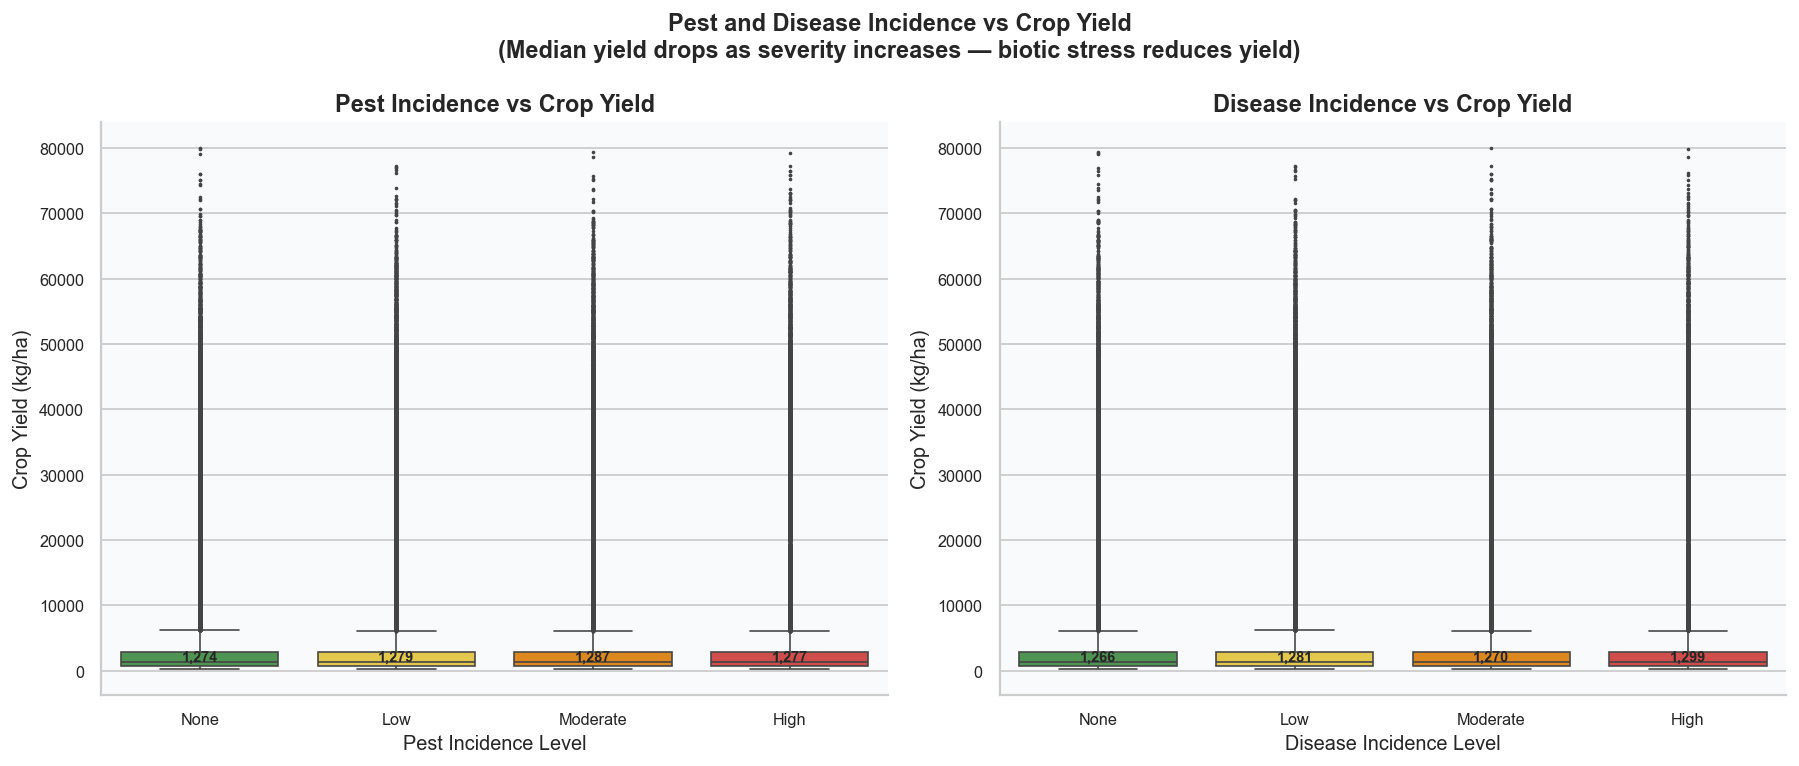

In [17]:
# PLOT 7 — PEST AND DISEASE INCIDENCE vs YIELD  (Box Plot)

print("Plot 7 : Pest and Disease Incidence vs Yield")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Pest and Disease Incidence vs Crop Yield\n"
    "(Median yield drops as severity increases — biotic stress reduces yield)",
    fontsize=13, fontweight="bold"
)

pest_order   = ["None", "Low", "Moderate", "High"]
pest_palette = {
    "None"    : "#43A047",
    "Low"     : "#FDD835",
    "Moderate": "#FB8C00",
    "High"    : "#E53935"
}

# Left — Pest Incidence
df_pest = df[df["Pest_Incidence"].isin(pest_order)]
sns.boxplot(
    data=df_pest,
    x="Pest_Incidence",
    y="Crop_Yield_kg_ha",
    order=pest_order,
    hue="Pest_Incidence",              
    palette=pest_palette,
    legend=False,                     
    fliersize=1, linewidth=0.9,
    ax=axes[0]
)
axes[0].set_title("Pest Incidence vs Crop Yield")
axes[0].set_xlabel("Pest Incidence Level")
axes[0].set_ylabel("Crop Yield (kg/ha)")

# Annotate median drop
medians = [
    df_pest[df_pest["Pest_Incidence"] == level]["Crop_Yield_kg_ha"].median()
    for level in pest_order
]
for i, (level, med) in enumerate(zip(pest_order, medians)):
    axes[0].text(
        i, med + 200, f"{med:,.0f}",
        ha="center", fontsize=8, fontweight="bold"
    )

# Right — Disease Incidence
df_dis = df[df["Disease_Incidence"].isin(pest_order)]
sns.boxplot(
    data=df_dis,
    x="Disease_Incidence",
    y="Crop_Yield_kg_ha",
    order=pest_order,
    hue="Disease_Incidence",           
    palette=pest_palette,
    legend=False,                      
    fliersize=1, linewidth=0.9,
    ax=axes[1]
)
axes[1].set_title("Disease Incidence vs Crop Yield")
axes[1].set_xlabel("Disease Incidence Level")
axes[1].set_ylabel("Crop Yield (kg/ha)")

dis_medians = [
    df_dis[df_dis["Disease_Incidence"] == level]["Crop_Yield_kg_ha"].median()
    for level in pest_order
]
for i, (level, med) in enumerate(zip(pest_order, dis_medians)):
    axes[1].text(
        i, med + 200, f"{med:,.0f}",
        ha="center", fontsize=8, fontweight="bold"
    )

plt.tight_layout()
plt.show()

# save(fig, "main_plot7_pest_disease_vs_yield.png")

Plot 8 : Yield Category Proportion by Crop (Stacked Bar)


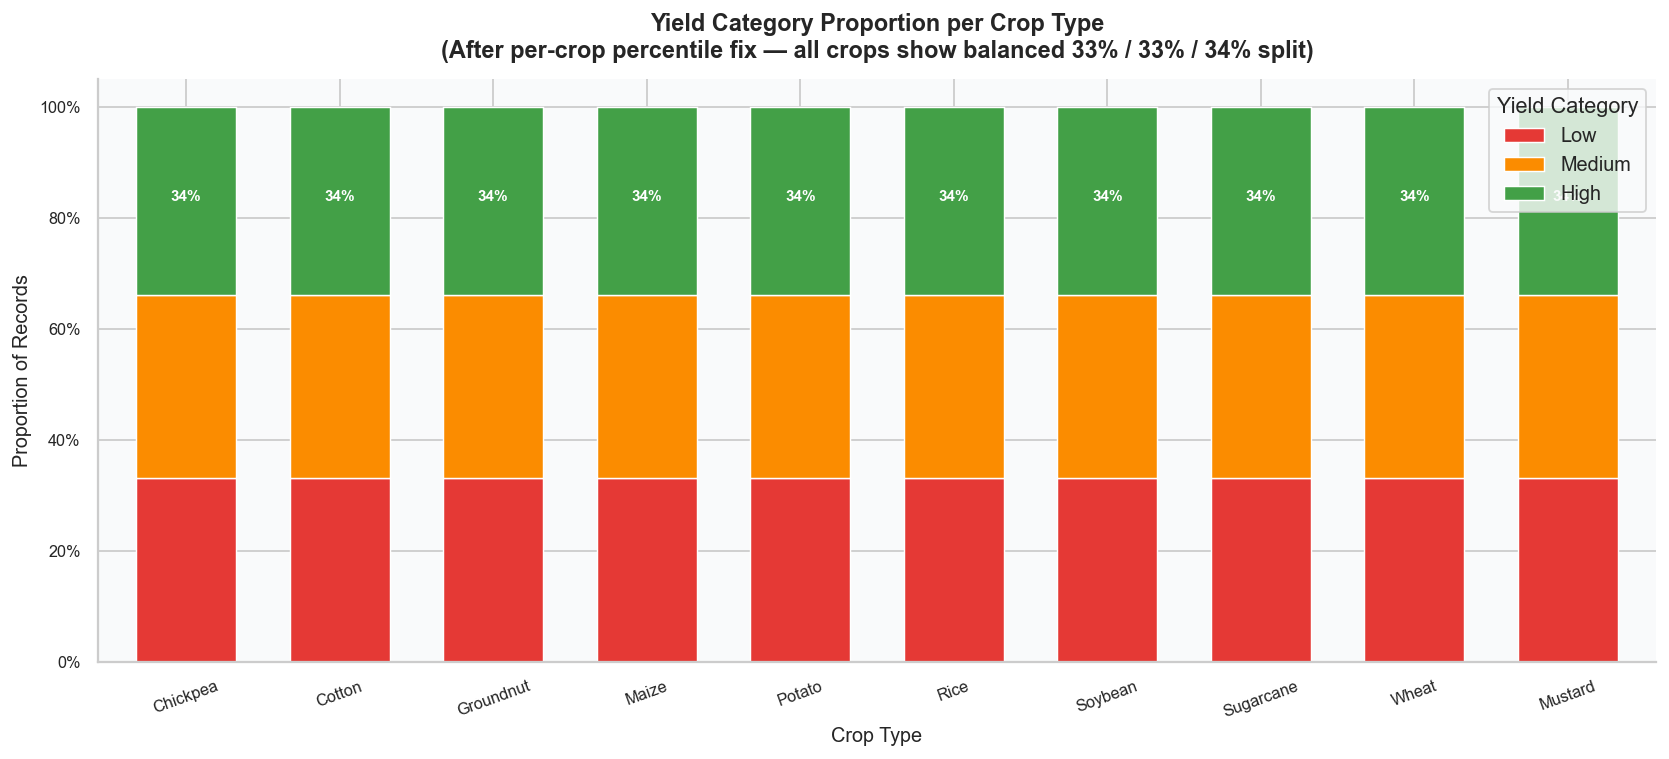

In [18]:
# PLOT 8 — YIELD CATEGORY PROPORTION BY CROP  (Stacked Bar)

print("Plot 8 : Yield Category Proportion by Crop (Stacked Bar)")


fig, ax = plt.subplots(figsize=(13, 6))

# Build proportion table
prop_df = (
    df.groupby(["Crop_Type", "Yield_Category"])
    .size()
    .unstack(fill_value=0)
)
# Normalise rows to proportions
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0)

# Keep correct column order and sort by High proportion
prop_df = prop_df[["Low", "Medium", "High"]]
prop_df = prop_df.sort_values("High", ascending=False)

prop_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#E53935", "#FB8C00", "#43A047"],
    edgecolor="white",
    linewidth=0.8,
    width=0.65
)

ax.set_xlabel("Crop Type")
ax.set_ylabel("Proportion of Records")
ax.set_title(
    "Yield Category Proportion per Crop Type\n"
    "(After per-crop percentile fix — all crops show balanced 33% / 33% / 34% split)",
    pad=12
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title="Yield Category", loc="upper right")
ax.tick_params(axis="x", rotation=20)

# Annotate High % inside each green bar
for i, (crop, row) in enumerate(prop_df.iterrows()):
    high_y = row["Low"] + row["Medium"] + row["High"] / 2
    ax.text(
        i, high_y,
        f"{row['High']:.0%}",
        ha="center", fontsize=8.5,
        fontweight="bold", color="white"
    )
    
plt.tight_layout()
plt.show()
# save(fig, "main_plot8_yield_category_stacked.png")